### Weight Initialization
#### Definition
Weight Initialization is the process of assigning initial values to weights before training begins.

Before Gradient Descent starts:
```
Neural Network
      ↓
Random Weights
      ↓
Training Begins
```

A neural network does **not** start with learned weights.

It starts with initialized weights and learns from there.

### Why Is Weight Initialization Important?
Bad initialization can cause:
* No Learning
* Slow Learning
* Vanishing Gradients
* Exploding Gradients

Even if:
* Architecture is correct
* Dataset is good
* Learning rate is good

the model may still fail.

#### Example
Suppose all weights are initialized to:
```
W = 0
```

**Diagram:**

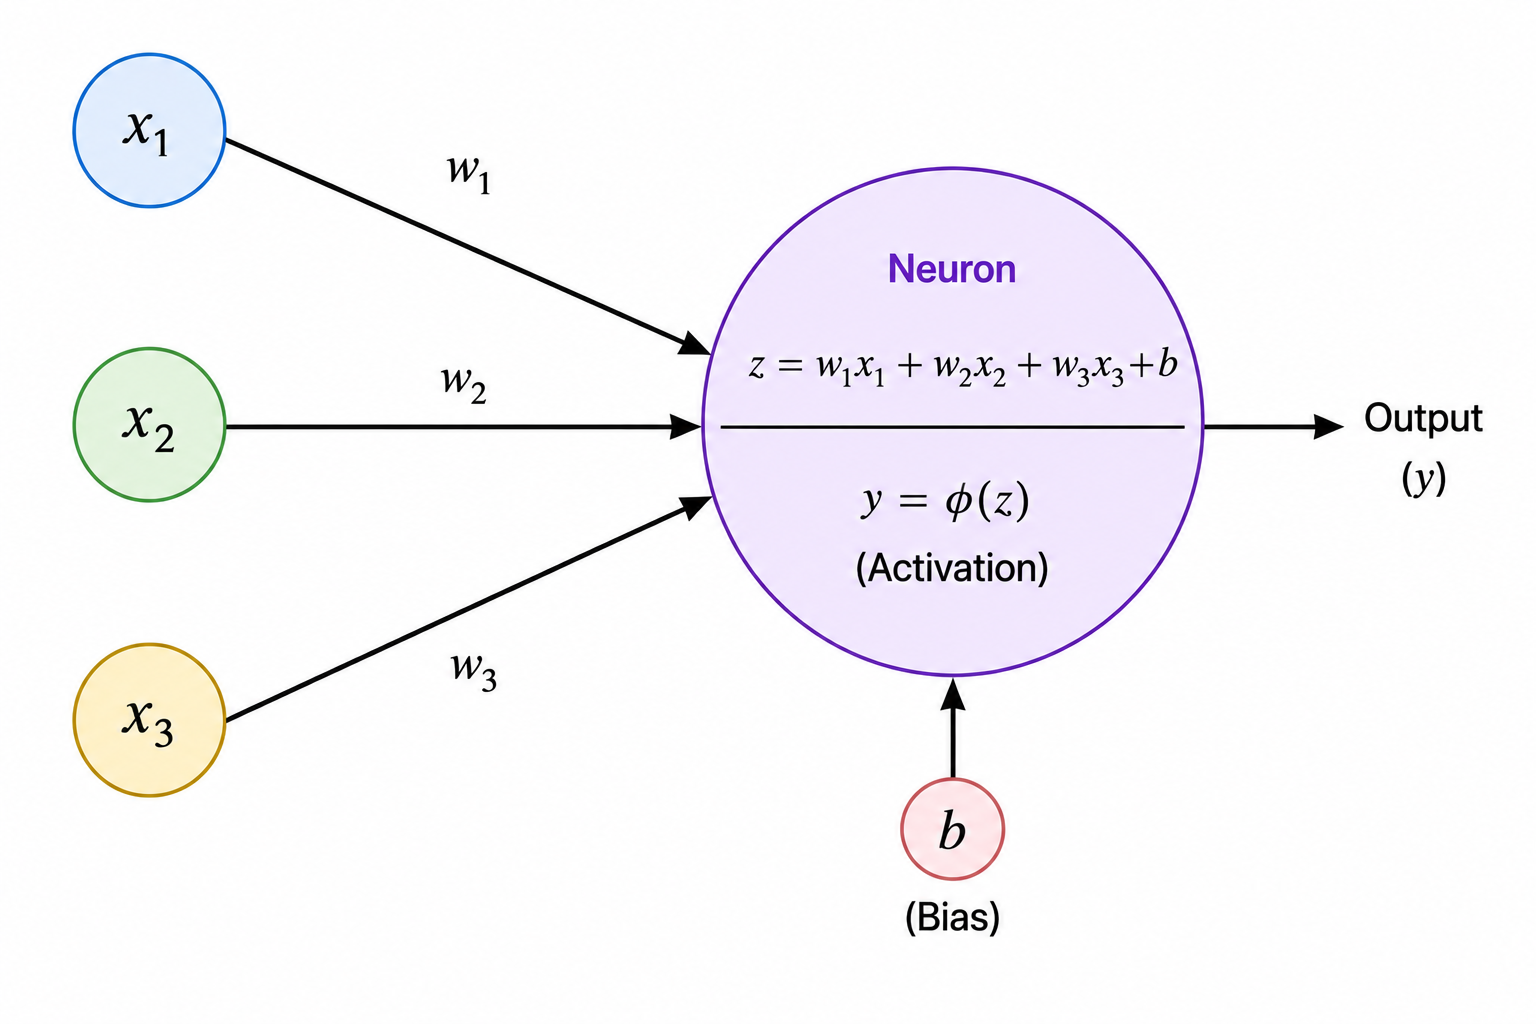

All neurons receive identical weights.

Result:
```
All neurons learn the same thing
```

This is called: **Symmetry Problem**

The network loses its ability to learn diverse features.

### Bad Initialization Example
#### Too Small
```
0.00001
0.00002
0.00003
```

Result:
```
Signals become tiny
      ↓
Gradients become tiny
      ↓
Learning slows
```

#### Too Large
```
100
200
300
```

Result:
```
Activations explode
      ↓
Gradients explode
      ↓
Training unstable
```

### Goal of Good Initialization
We want:
```
Inputs
   ↓
Layer 1
   ↓
Layer 2
   ↓
Layer 3
   ↓
Output
```

without values becoming:
```
Too Small
```

or
```
Too Large
```

across layers.

### Xavier Initialization (Glorot Initialization)
#### When Used?
Typically with:
* Sigmoid
* Tanh

activations.

#### Intuition
Keep variance approximately constant across layers.

Instead of:
```
Layer 1 → Large Values
Layer 2 → Huge Values
Layer 3 → Massive Values
```

or
```
Layer 1 → Small Values
Layer 2 → Tiny Values
Layer 3 → Almost Zero
```

Xavier tries to maintain stable signal flow.

#### Simplified Formula

For a layer:
```
fan_in  = number of input neurons
fan_out = number of output neurons
```

Weights are initialized using:
```
Variance ≈ 2 / (fan_in + fan_out)
```

No need to memorize the formula.

Just remember:
```
Xavier
↓
Sigmoid / Tanh
↓
Stable Activations
```

### He Initialization
#### When Used?
Typically with:
* ReLU
* Leaky ReLU

This is the most common initialization in modern Deep Learning.

#### Why Needed?
ReLU sets all negative values to:
```
0
```

#### Flow:
```
Input
  ↓
ReLU
  ↓

Negative → 0
Positive → Pass
```

This changes activation distribution.

Xavier is not ideal here.

#### Solution
He Initialization compensates for ReLU behavior.

#### Simplified Formula
```
Variance ≈ 2 / fan_in
```

Remember:
```
ReLU
↓
He Initialization
```

### Quick Comparison
| Initialization | Common Activation |
| -------------- | ----------------- |
| Xavier         | Sigmoid, Tanh     |
| He             | ReLU, Leaky ReLU  |

### Modern Practice
For most networks:
* ReLU
* Leaky ReLU

are common.

Therefore:

```text
He Initialization
```

is usually the default choice.

PyTorch and TensorFlow often apply suitable initialization automatically.

### PyTorch Example

In [1]:
import torch
import torch.nn as nn

layer = nn.Linear(128, 64)

nn.init.kaiming_uniform_(
    layer.weight
)

Parameter containing:
tensor([[ 0.0081,  0.0700,  0.0632,  ...,  0.0357, -0.0351,  0.0500],
        [ 0.0600, -0.0060,  0.0461,  ..., -0.1928,  0.1795,  0.0098],
        [-0.0204,  0.0268, -0.1699,  ..., -0.1380,  0.1547, -0.1932],
        ...,
        [-0.1126,  0.0092, -0.0633,  ...,  0.1235,  0.1286,  0.1428],
        [-0.0119,  0.0738,  0.0399,  ...,  0.1657,  0.0292, -0.0834],
        [ 0.0832, -0.1490,  0.0586,  ...,  0.0068, -0.1060, -0.1883]],
       requires_grad=True)

**kaiming = He Initialization.**